## Спринт 1.
Задачи:
- Найти по крайней мере 5 современных оптимизаторов, заполнить информацию о них: название, дата выхода, гиперпараметры, идея, список статей по ним
- Посмотреть зарубежные исследования по применению оптимизаторов, посмотреть на датасеты, которые там используются (отчет)
- Обучение простой нейронной сети для задачи регрессии (желательно использовать датасеты из исследований) (notebook)


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
pd.set_option('display.max_colwidth', None)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
#import warnings
#warnings.filterwarnings("ignore")
import sys
import os
#os.environ["RAY_PICKLE_VERBOSE_DEBUG"] = "1"
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/california-housing-prices/S7_california_housing_train.csv
/kaggle/input/california-housing-prices/S7_california_housing_test.csv


In [2]:
%pip install lion_pytorch adabound torch-optimizer optax ray[tune] adabelief-pytorch==0.2.0 -q
%pip install --upgrade seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 4.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 5.3 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


Импортируем необходимые модули.  

In [3]:
from datetime import datetime

import os

from copy import copy

from typing import Optional, Dict, Tuple, List

from pprint import pprint

import time

import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
from torch import nn
import torch.utils.tensorboard
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset, random_split
import torchmetrics
from torchmetrics.regression import MeanAbsolutePercentageError as MAPE, R2Score
from torchmetrics.classification import Accuracy, MulticlassConfusionMatrix, F1Score, MulticlassROC
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2, ToTensor
from torchinfo import summary

from tqdm import tqdm

import ray
from ray import tune
from ray.tune import JupyterNotebookReporter
from ray.tune.schedulers import ASHAScheduler

from adabound import AdaBound
from torch_optimizer import Adahessian as AdaHessian
from optax import fromage as Fromage
from adabelief_pytorch import AdaBelief
from lion_pytorch import Lion

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cuda" if torch.cuda.is_available() else device)
device

device(type='cuda')

Введем функцию `preprocess_data`, которая читает данные в формате `csv` и преобрабатывает их.  

In [5]:
def preprocess_data(filename: str) -> torch.Tensor:
    """Function to preprocess data

    Args:
        filename (str): Filename of data to be preprocessed.

    Returns:
        torch.Tensor: preprocessed data
    """
    data = pd.read_csv(filename)
    
    data_t = torch.Tensor(data.values)
    data_t = torch.nn.functional.normalize(data_t)
    
    return data_t


Введем функцию `create_writer`, возвращающую объект класса `SummaryWriter` для записи всех экспериментов с разными параметрами.  

In [6]:
def create_writer(
    experiment_name: str,
    model_name: str,
    extra: Optional[str] = None,
) -> torch.utils.tensorboard.writer.SummaryWriter:
    """Creates a torch.utils.tensorboard.writer.SummaryWriter instance saving to log_dir.
    log_dir is a combination of runs/timestamp/experiment_name/model_name/extra.
    timestamp at format YYYY-MM-DD.
    Args:
        experiment_name (str): Name of the experiment.
        model_name (str): Name of model.
        extra (Optional[str]): Anything extra to add to the directory. Defaults to None.

    Returns:
        torch.utils.tensorboard.writer.SummaryWriter: SummaryWriter for tracking experiment results.
    """
    timestamp = datetime.now().strftime("%Y-%m-%d")
    if extra:
        log_dir = os.path.join("runs", timestamp, experiment_name, model_name, extra)
    else:
        log_dir = os.path.join("runs", timestamp, experiment_name, model_name)

    print(f"[INFO] Created SummaryWriter, saving to: {log_dir}...")
    return torch.utils.tensorboard.SummaryWriter(log_dir=log_dir)

Введем 3 функции: `train` - в ней реализован цикл обучения модели, `train_step` и `valid_step` - функции одной итерации для обучения модели и ее валидации.  

In [7]:
def train_step(
    model: nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: nn.Module,
    metrics: Dict[str, torchmetrics.Metric],
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> Dict[str, float]:
    """Trains a PyTorch model for a single epoch.

    Turns a target PyTorch model to training mode and then
    runs through all of the required training steps (forward
    pass, loss calculation, optimizer step).

    Args:
        model (nn.Module): A PyTorch model to be trained.
        dataloader (torch.utils.data.DataLoader): A data to used for training.
        loss_fn (nn.Module): A PyTorch loss function to minimize.
        metrics (List[torchmetrics.Metric]): A list of metrics used for evaluating.
        optimizer (torch.optim.Optimizer): A PyTorch optimizer to help minimize the loss function.
        device (torch.device): A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
        A Dict[str, float] with key-value pairs as name metric and its value.
    """
    model.train()
    metric_results = {"train_loss": 0.}

    for batch, (X, y) in enumerate(dataloader):

        X, y = X.to(device), y.to(device)
    
        y_pred = model(X)
    
        loss = loss_fn(y_pred, y)
        
        metric_results["train_loss"] += loss.item()
        for metric in metrics:
            metrics[metric].update(y_pred, y)
    
        optimizer.zero_grad()
    
        loss.backward(create_graph=True) if isinstance(optimizer, AdaHessian) else loss.backward()
    
        optimizer.step()

    metric_results["train_loss"] /= len(dataloader)

    for metric in metrics:
        metric_computed = metrics[metric].compute()
        metric_results["train_" + metric] = metric_computed.item() if not isinstance(metric_computed, tuple) and metric_computed.numel() == 1 else metric_computed
        metrics[metric].reset()

    return metric_results

In [8]:
def valid_step(
    model: nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: nn.Module,
    metrics: Dict[str, torchmetrics.Metric],
    device: torch.device,
) -> Dict[str, float]:
    """Validates a PyTorch model for a single epoch.

    Turns a target PyTorch model to "eval" mode and then performs
    a forward pass on a validating dataset.

    Args:
        model (nn.Module): A PyTorch model to be tested.
        dataloader (torch.utils.data.DataLoader): A data to used for validating.
        loss_fn (nn.Module): A PyTorch loss function to minimize.
        metrics (List[torchmetrics.Metric]): A list of metrics used for evaluating.
        device (torch.device): A target device to compute on ("cuda", "cpu", "mps").

    Returns:
        A Dict[str, float] with key-value pairs as name metric and its value.
    """
    model.eval()
    metric_results = {"valid_loss": 0.}
    
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            test_pred = model(X)
    
            loss = loss_fn(test_pred, y)
            
            metric_results["valid_loss"] += loss.item()
            for metric in metrics:
                metrics[metric].update(test_pred, y)
            
    metric_results["valid_loss"] /= len(dataloader)
    for metric in metrics:
        metric_computed = metrics[metric].compute()
        metric_results["valid_" + metric] = metric_computed.item() if not isinstance(metric_computed, tuple) and metric_computed.numel() == 1 else metric_computed
        metrics[metric].reset()
    return metric_results

In [9]:
def train(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    valid_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    metrics: Dict[str, torchmetrics.Metric],
    epochs: int,
    device: torch.device,
    scheduler: Optional[torch.optim.lr_scheduler.ReduceLROnPlateau] = None,
    writer: Optional[torch.utils.tensorboard.SummaryWriter] = None,
    epoch_step: int = 10
)-> Dict[str, List]:
    """Trains and valids a PyTorch model.

    Passes a target PyTorch models through train_step() and valid_step()
    functions for a number of epochs, training and validating the model
    in the same epoch loop.

    Calculates, prints and stores evaluation metrics throughout.

    Args:
        model: A PyTorch model to be trained and tested.
        train_dataloader (torch.utils.data.DataLoader): A data to used for training.
        valid_dataloader (torch.utils.data.DataLoader): A data to used for validating.
        test_dataloader (torch.utils.data.DataLoader): A data to used for testing.
        optimizer: A PyTorch optimizer to help minimize the loss function.
        loss_fn: A PyTorch loss function to calculate loss on both datasets.
        metrics (List[torchmetrics.Metric]): A list of metrics used for training and evaluating.
        epochs: An integer indicating how many epochs to train for.
        device: A target device to compute on (e.g. "cuda", "cpu", "mps").
        scheduler: A LRScheduler intance for interrupting training.
        writer: A SummaryWriter intance for writing experiment results.
        epoch_step: A number to represent step count to output information about training.

    Returns:
        Dict[str, List]: A dictionary of training and validating loss as well as training and
        validating metrics.
    """
    results: Dict[str, List] = {
        "train_loss": [],
        "valid_loss": [],
    }

    for metric in metrics:
        metrics[metric] = metrics[metric].to(device)
        results[f'train_{metric}'] = []
        results[f'valid_{metric}'] = []

    for epoch in range(epochs):
        train_results = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            metrics=copy(metrics),
            optimizer=optimizer,
            device=device,
        )
        
        if scheduler is not None:
            scheduler.step(train_results["train_loss"])
            
        valid_results = valid_step(
            model=model,
            dataloader=valid_dataloader,
            loss_fn=loss_fn,
            metrics=copy(metrics),
            device=device,
        )
        if epoch % epoch_step == 0:
            for metric in train_results.keys():
                results[metric].append(train_results[metric])

            for metric in valid_results.keys():
                results[metric].append(valid_results[metric])

            if writer is not None:
                writer.add_scalars(
                    main_tag="Loss",
                    tag_scalar_dict=train_results | valid_results,
                    global_step=epoch,
                )

                writer.close()
            else:
                pass
    test_results = valid_step(
        model=model, 
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        metrics=metrics,
        device=device,
    )
    results["test_loss"] = test_results["valid_loss"]
    for metric in metrics:
        results["test_" + metric] = test_results["valid_" + metric]
    return results

Создадим бейcлайн `SimpleRegressionModel`.  

In [10]:
class SimpleRegressionModel(nn.Module):
    def __init__(
        self,
        input_shape: int = 8,
        hidden_units: int = 16,
        output_shape: int = 1,
        activation_function: Optional[torch.nn.Module] = None,
        normalization: Optional[torch.nn.Module] = None,
        dropout: Optional[torch.nn.Module] = None,
    ) -> None:
        """SimpleRegressionModel initializer

        Args:
            input_shape (int): Number of units in input layer
            hidden_units (int): Number of units in hidden layers
            output_shape (int): Number of units in output layer
            activation_function (Optional[torch.nn.Module], optional): Activation function. Defaults to None.
            normalization (Optional[torch.nn.Module], optional): Use batch or layer normalization. Defaults to None.
            dropout (Optional[torch.nn.Module], optional): Dropout layer. Defaults to None.
        """
        super().__init__()

        self.block = nn.Sequential(
            nn.Linear(
                in_features=input_shape,
                out_features=hidden_units,
                device=device,
            ),
            nn.Identity() if normalization is None else normalization,
            nn.Identity() if activation_function is None else activation_function,
            nn.Identity() if dropout is None else dropout,
            nn.Linear(
                in_features=hidden_units,
                out_features=output_shape,
                device=device,
            ),
        )

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """Method for forward pass.

        Args:
            X (torch.Tensor): Input data.

        Returns:
            torch.Tensor: Result of computations.
        """
        return self.block(X)

## Спринт 2.  
- Ознакомиться с подходами BatchNorm, LayerNorm, Dropout. Внедрить их в текущую сеть. Изучить виды функций активации, чем они отличаются и протестировать изменение точности модели при смене функции активации
- Попробовать на практике применить алгоритмы AdaBelief, AdamW (пока базовые варианты без подбора параметров), посмотреть что происходит с точностью модели, сравнить с результатами LION


Зададим словари параметров модели и оптимизаторов, сделаем их подбор с использованием библиотеки `ray`.  

In [11]:
ray.shutdown()
ray.init(runtime_env={"env_vars": {"RAY_AIR_RICH_LAYOUT": "1"}},)
pprint(ray.cluster_resources())

2025-04-29 14:04:29,454	INFO worker.py:1841 -- Started a local Ray instance.


{'CPU': 4.0,
 'GPU': 2.0,
 'accelerator_type:T4': 1.0,
 'memory': 17791738676.0,
 'node:172.19.2.2': 1.0,
 'node:__internal_head__': 1.0,
 'object_store_memory': 8895869337.0}


In [12]:
def get_train_valid_test_datasets(train_filename: str, 
                                  test_filename: str) -> Tuple[TensorDataset, ...]:
    train_df = pd.read_csv(train_filename)
    test_df = pd.read_csv(test_filename)
    
    X_train, X_valid, y_train, y_valid = train_test_split(train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values,
                                                         random_state=0)
    
    X_train_np = X_train.astype(np.float32)
    y_train_np = y_train.astype(np.float32).reshape(-1, 1)
    X_valid_np = X_valid.astype(np.float32)
    y_valid_np = y_valid.astype(np.float32).reshape(-1, 1)
    
    X_test_np = test_df.iloc[:, :-1].values.astype(np.float32)
    y_test_np = test_df.iloc[:, -1].values.astype(np.float32).reshape(-1, 1)
    
    scaler = StandardScaler()
    X_train_scaled_np = scaler.fit_transform(X_train_np)
    X_valid_scaled_np = scaler.fit_transform(X_valid_np)
    X_test_scaled_np = scaler.transform(X_test_np)
    
    X_train_tensor = torch.tensor(X_train_scaled_np, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)
    X_valid_tensor = torch.tensor(X_valid_scaled_np, dtype=torch.float32)
    y_valid_tensor = torch.tensor(y_valid_np, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_scaled_np, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    return train_dataset, valid_dataset, test_dataset

train_filename = "/kaggle/input/california-housing-prices/S7_california_housing_train.csv"
test_filename = "/kaggle/input/california-housing-prices/S7_california_housing_test.csv"

train_dataset, valid_dataset, test_dataset = get_train_valid_test_datasets(train_filename=train_filename,
                                                                          test_filename=test_filename)


In [13]:
torch.set_num_threads(4)
INPUT_SHAPE = 8
HIDDEN_UNITS = 16
OUTPUT_SHAPE = 1
NUM_EPOCHS = 31
EPOCH_STEP = 5
BATCH_SIZE = 512
np.random.seed(0)
torch.manual_seed(0)

optimizer_params = {
    AdaHessian: {"lr": tune.grid_search([1e-2, 1e-1, 0.15, 1.]),
                 "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
                 "hessian_power": tune.grid_search([0.25, 0.5, 0.75, 1.]),
                },
    Lion: {"lr": tune.grid_search([1e-5, 1e-4, 1e-3, 1e-2]),
           "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
           "decoupled_weight_decay": tune.grid_search([False, True]),
           "use_triton": tune.grid_search([False]),
          },
    AdaBelief: {"lr": tune.grid_search([1e-4, 1e-3, 1e-2]),
                "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
                "amsgrad": tune.grid_search([False, True]),
                "weight_decouple": tune.grid_search([False, True]),
                "rectify": tune.grid_search([False, True]),
                "print_change_log": tune.grid_search([False])},
    AdamW: {"lr": tune.grid_search([1e-4, 1e-3, 1e-2]),
            "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
            "amsgrad": tune.grid_search([False, True])},
    AdaBound: {"lr": tune.grid_search([1e-4, 1e-3, 1e-2]),
               "final_lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
               "gamma": tune.grid_search([1e-4, 1e-3, 1e-2]),
               "weight_decay": tune.grid_search([0, 1e-4, 1e-3]),
               "amsbound": tune.grid_search([False, True])},
}

writer = create_writer(
    experiment_name="regression",
    model_name="simple_reg_model", 
)

analysis_optimizer = {}
metrics = {"mape": MAPE(), "r2score": R2Score()}

reporter = JupyterNotebookReporter(metric_columns=["test_loss"], 
                                   mode="min", 
                                   print_intermediate_tables=False)

train_dataloader = DataLoader(train_dataset, 
                              batch_size=BATCH_SIZE,
                              pin_memory=True,
                              num_workers=2,
                              shuffle=True)
valid_dataloader = DataLoader(valid_dataset,
                             batch_size=BATCH_SIZE,
                             num_workers=2,
                             pin_memory=True,
                             shuffle=False)
test_dataloader = DataLoader(test_dataset,
                             batch_size=BATCH_SIZE,
                             num_workers=2,
                             pin_memory=True,
                             shuffle=False)

for metric in metrics:
    reporter.add_metric_column(f"valid_{metric}")

for optimizer_type in optimizer_params.keys():
    def wrap(config: dict) -> None:
        """Wrapper function for tuning hyperparameters.
    
        Args:
            config: A dict whose keys are parameters to be tuned and values that the parameter can take.

        """
        model = SimpleRegressionModel(input_shape=8, 
                                      hidden_units=16, 
                                      output_shape=1, 
                                      activation_function=nn.ReLU(),
                                     ).to(device)
        loss_fn = torch.nn.MSELoss()
        optimizer = optimizer_type(model.parameters(), **{i: config[i] for i in config if i in optimizer_params[optimizer_type]})
        # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        #     optimizer, mode="min", patience=5, factor=0.5, verbose=True
        # )
        d = train(
             model=model,
             train_dataloader=train_dataloader,
             valid_dataloader=valid_dataloader,
             test_dataloader=test_dataloader,
             loss_fn=loss_fn,
             metrics=metrics,
             optimizer=optimizer,
             epochs=NUM_EPOCHS,
             device=device,
             #scheduler=scheduler,
             epoch_step=EPOCH_STEP,
        )
        tune.report({"test_loss": d["test_loss"]} | {f"test_{str(i)}": d[f"test_{str(i)}"] for i in metrics})
        
    analysis = tune.run(
        wrap,
        config={str(key): value for key, value in optimizer_params[optimizer_type].items()},
        scheduler=ASHAScheduler(metric=f'test_r2score', mode='max'),
        progress_reporter=reporter,
        resources_per_trial={"cpu": 2, 
                             "gpu": 1,
                             },
        log_to_file=True,
    )
    analysis_optimizer[optimizer_type] = analysis


2025-04-29 14:04:30,984	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(pid=481) 2025-04-29 14:04:53.222503: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=481) 2025-04-29 14:04:53.245168: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=481) 2025-04-29 14:04:53.252045: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(wrap pid=481) /usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:825: Use

Trial name,test_loss,test_mape,test_r2score
wrap_df034_00000,nan,nan,nan
wrap_df034_00001,nan,nan,nan
wrap_df034_00002,4.30661e+09,0.274899,0.663214
wrap_df034_00003,5.40902e+09,0.397435,0.577182
wrap_df034_00004,nan,nan,nan
wrap_df034_00005,nan,nan,nan
wrap_df034_00006,3.71084e+09,0.256906,0.709794
wrap_df034_00007,4.14716e+09,0.273815,0.675949
wrap_df034_00008,nan,nan,nan
wrap_df034_00009,nan,nan,nan


/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
(pid=1920) 2025-04-29 14:05:19.591935: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(pid=1920) 2025-04-29 14:05:19.617530: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=1920) 2025-04-29 14:05:19.624255: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: 

Trial name,test_loss,test_mape,test_r2score
wrap_eb210_00000,5.51462e+10,1,-3.31249
wrap_eb210_00001,5.51461e+10,0.999999,-3.31249
wrap_eb210_00002,5.5146e+10,0.999999,-3.31248
wrap_eb210_00003,5.5146e+10,0.999998,-3.31248
wrap_eb210_00004,5.51361e+10,0.999861,-3.3117
wrap_eb210_00005,5.51366e+10,0.999862,-3.31174
wrap_eb210_00006,5.4197e+10,0.987466,-3.2382
wrap_eb210_00007,5.41773e+10,0.987899,-3.23663
wrap_eb210_00008,5.51461e+10,0.999999,-3.31248
wrap_eb210_00009,5.51462e+10,1,-3.31249


(pid=48030) 2025-04-29 14:19:44.801890: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(pid=48030) 2025-04-29 14:19:44.823961: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=48030) 2025-04-29 14:19:44.830802: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered [repeated 2x across cluster]
(wrap pid=48032) *** SIGSEGV received at time=1745936402 on cpu 2 ***
(wrap pid=48032) PC: @     0x79afa5ada7ae  (unknown)  ray::gcs::TaskInfoAccessor::AsyncAddTaskEventData()
(wrap pid=48032)     @     0x79afa79f3520       3680  (unknown)
(w

...

2025-04-29 14:47:16,390	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/wrap_2025-04-29_14-26-10' in 0.0397s.
2025-04-29 14:47:16,412	INFO tune.py:1041 -- Total run time: 1265.53 seconds (1265.44 seconds for the tuning loop).
2025-04-29 14:47:16,515	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(pid=138387) 2025-04-29 14:47:24.762066: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(pid=138387) 2025-04-29 14:47:24.783262: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

Trial name,test_loss,test_mape,test_r2score
wrap_d82e3_00000,5.51458e+10,0.999995,-3.31246
wrap_d82e3_00001,5.51457e+10,0.999993,-3.31245
wrap_d82e3_00002,5.51228e+10,0.999699,-3.31066
wrap_d82e3_00003,5.51301e+10,0.99979,-3.31123
wrap_d82e3_00004,5.30296e+10,0.972691,-3.14684
wrap_d82e3_00005,5.27262e+10,0.968754,-3.12308
wrap_d82e3_00006,5.51458e+10,0.999994,-3.31246
wrap_d82e3_00007,5.51458e+10,0.999997,-3.31246
wrap_d82e3_00008,5.51262e+10,0.999719,-3.31092
wrap_d82e3_00009,5.51242e+10,0.999722,-3.31077


(pid=139826) 2025-04-29 14:47:52.143272: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(pid=138389) 2025-04-29 14:47:24.782888: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=138389) 2025-04-29 14:47:24.789495: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=139826) 2025-04-29 14:47:52.167648: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=139826) 2025-04-29 14:47:52.180527: E external/local_xla/xla/stream_

Trial name,test_loss,test_mape,test_r2score
wrap_99922_00000,4.44501e+09,0.279906,0.652112
wrap_99922_00001,4.50326e+09,0.28519,0.647776
wrap_99922_00002,nan,nan,nan
wrap_99922_00003,nan,nan,nan
wrap_99922_00004,nan,nan,nan
wrap_99922_00005,nan,nan,nan
wrap_99922_00006,nan,nan,nan
wrap_99922_00007,nan,nan,nan
wrap_99922_00008,nan,nan,nan
wrap_99922_00009,nan,nan,nan


(pid=157023) 2025-04-29 14:53:17.295865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(pid=157023) 2025-04-29 14:53:17.317671: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=157023) 2025-04-29 14:53:17.324603: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered [repeated 2x across cluster]
(wrap pid=155610) /usr/local/lib/python3.10/dist-packages/adabound/adabound.py:94: UserWarning: This overload of add_ is deprecated:
(wrap pid=155610) 	add_(Number alpha, Tensor other)
(wrap pid=155610) Consider using one of the following 

Выведем лучшие результаты подбора параметров в `DataFrame`.  

In [14]:
optimizer_comparison_mape_df = pd.DataFrame({"Optimizer": [repr(i)[repr(i).rfind('.') + 1: -2] for i in analysis_optimizer], 
                                        "Config": [i.get_best_config(metric=f"test_mape", mode="min") for i in analysis_optimizer.values()], 
                                        "MAPE": [i.get_best_trial(metric=f"test_mape", mode="min").last_result[f"test_mape"] for i in analysis_optimizer.values()], 
                                        "Time_total_s": [i.get_best_trial(metric=f"test_mape", mode="min").last_result['time_total_s'] for i in analysis_optimizer.values()],
                                       })

optimizer_comparison_mape_df

,Optimizer,Config,MAPE,Time_total_s
0,Adahessian,"{'lr': 0.1, 'weight_decay': 0.01, 'hessian_power': 0.75}",0.226841,16.500844
1,Lion,"{'lr': 0.01, 'weight_decay': 0.001, 'decoupled_weight_decay': False, 'use_triton': False}",0.987170,15.305286
2,AdaBelief,"{'lr': 0.01, 'weight_decay': 0.01, 'amsgrad': True, 'weight_decouple': True, 'rectify': False, 'print_change_log': False}",0.395858,15.805541
3,AdamW,"{'lr': 0.01, 'weight_decay': 0, 'amsgrad': True}",0.968754,15.968511
4,AdaBound,"{'lr': 0.01, 'final_lr': 0.0001, 'gamma': 0.0001, 'weight_decay': 0.0001, 'amsbound': True}",0.240022,16.224577


In [15]:
optimizer_comparison_r2score_df = pd.DataFrame({"Optimizer": [repr(i)[repr(i).rfind('.') + 1: -2] for i in analysis_optimizer], 
                                        "Config": [i.get_best_config(metric=f"test_r2score", mode="max") for i in analysis_optimizer.values()], 
                                        "R2Score": [i.get_best_trial(metric=f"test_r2score", mode="max").last_result[f"test_r2score"] for i in analysis_optimizer.values()], 
                                        "Time_total_s": [i.get_best_trial(metric=f"test_r2score", mode="max").last_result['time_total_s'] for i in analysis_optimizer.values()],
                                       })

optimizer_comparison_r2score_df

,Optimizer,Config,R2Score,Time_total_s
0,Adahessian,"{'lr': 0.1, 'weight_decay': 0.0001, 'hessian_power': 0.75}",0.727418,16.856030
1,Lion,"{'lr': 0.01, 'weight_decay': 0.001, 'decoupled_weight_decay': False, 'use_triton': False}",-3.235809,15.305286
2,AdaBelief,"{'lr': 0.01, 'weight_decay': 0, 'amsgrad': False, 'weight_decouple': True, 'rectify': False, 'print_change_log': False}",0.337774,15.915536
3,AdamW,"{'lr': 0.01, 'weight_decay': 0, 'amsgrad': True}",-3.123078,15.968511
4,AdaBound,"{'lr': 0.001, 'final_lr': 0.0001, 'gamma': 0.0001, 'weight_decay': 0.001, 'amsbound': False}",0.681071,15.699806


**Анализ по оптимизаторам:**

1. Adahessian

* R2 Config: {'lr': 0.1, 'weight_decay': 0.0001, 'hessian_power': 0.75} | R2 = 0.7274 (Лучший)

* MAPE Config: {'lr': 0.1, 'weight_decay': 0.01, 'hessian_power': 0.75} | MAPE = 0.2268 (Лучший)

* Анализ: Adahessian показал лучшие результаты по обеим метрикам, хотя и с разными weight_decay. Высокий lr=0.1 снова оказался эффективным (типично для Adahessian). Для R2 потребовалась минимальная регуляризация (wd=0.0001), а для минимизации MAPE - более сильная (wd=0.01). Это говорит о том, что информация о кривизне (Гессиан) помогает эффективно находить хорошие решения для этой регрессионной задачи, обеспечивая стабильность даже при высоком lr. Разная оптимальная регуляризация для R2 и MAPE может указывать на то, что более сильная регуляризация помогает избежать отдельных очень больших процентных ошибок (что влияет на MAPE), но может слегка ухудшить общую подгонку по дисперсии (R2).

* Итог: Явный лидер для данной задачи и модели.

2. Lion

* R2 Config: {'lr': 0.01, 'weight_decay': 0.001, 'decoupled_weight_decay': False, ...} | R2 = -3.2358

* MAPE Config: {'lr': 0.01, 'weight_decay': 0.001, 'decoupled_weight_decay': False, ...} | MAPE = 0.9871

* Анализ: Lion показал плохие результаты по обеим метрикам. Отрицательный R2 означает, что модель предсказывает хуже, чем простое среднее значение, MAPE, близкий к 1, говорит о том, что модель не смогла выявить закономерность в данных. Причина таких плохих результатов, может быть в том, что Lion не способен обучить модель, основанной на слишком уж простой архитектуре.

* Итог: Примитивная архитектура модели, возможно, стала причиной таких результатов

3. AdaBelief

* R2 Config: {'lr': 0.01, 'weight_decay': 0, 'amsgrad': False, 'weight_decouple': True, ...} | R2 = 0.3378

* MAPE Config: {'lr': 0.01, 'weight_decay': 0.01, 'amsgrad': True, 'weight_decouple': True, ...} | MAPE = 0.3959

* Анализ: AdaBelief показал слабые результаты. lr=0.01 (самый высокий в сетке поиска) снова кажется подозрительно высоким. Для R2 лучшая конфигурация была без регуляризации (wd=0), что дало плохой результат. Для MAPE потребовалась сильная регуляризация (wd=0.01) и amsgrad=True, что улучшило MAPE (но он все еще не очень хороший) по сравнению с тем, что было бы без них, но, вероятно, ухудшило R2. weight_decouple=True имеет значение только при wd > 0.

* Итог: Не смог достичь хороших результатов. Вероятно, адаптивный механизм AdaBelief был не так эффективен на этой задаче, как Adahessian. Показал чувствительность к регуляризации.

4. AdamW

* R2 Config: {'lr': 0.01, 'weight_decay': 0, 'amsgrad': True} | R2 = -3.1231

* MAPE Config: {'lr': 0.01, 'weight_decay': 0, 'amsgrad': True} | MAPE = 0.9688

* Анализ: Как и Lion, AdamW показал плохие результаты с одинаковой конфигурацией для обеих метрик. AdamW не подходит для решения данной задачи при такой архитектуре модели.

* Итог:  Примитивная архитектура модели, возможно, стала причиной таких результатов

5. AdaBound

* R2 Config: {'lr': 0.001, 'final_lr': 0.0001, 'gamma': 0.0001, 'weight_decay': 0.001, ...} | R2 = 0.6811 (Хорошо)

* MAPE Config: {'lr': 0.01, 'final_lr': 0.0001, 'gamma': 0.0001, 'weight_decay': 0.0001, ...} | MAPE = 0.2400 (Хорошо)

* Анализ: AdaBound показал хорошие результаты, заняв второе место после Adahessian. Интересно, что для R2 оптимальным был более низкий начальный lr=0.001 и умеренная регуляризация wd=0.001. Для MAPE же сработал более высокий lr=0.01, но с очень слабой регуляризацией wd=0.0001. Вероятно, механизм ограничения lr (динамические границы), заданный final_lr=0.0001 (очень низкий) и gamma=0.0001 (переход происходит поздно или границы широкие вначале), помог стабилизировать обучение даже при lr=0.01 в случае MAPE, предотвратив расхождение, которое наблюдалось у AdamW и Lion.

* Итог: Показал себя гибким и стабильным, найдя хорошие (хотя и разные) конфигурации для обеих метрик. Механизм границ, вероятно, сыграл положительную роль.

**Общие выводы по California Housing:**

* Adahessian - победитель: Использование информации о кривизне оказалось наиболее выгодным для этой регрессионной задачи с простой моделью, обеспечив лучшие R2 и MAPE.

* Lion и AdamW: не смогли при достаточно простотой модели, при особенностях задачи показать хорошие результаты

* AdaBound - хороший компромисс: Показал стабильность и хорошие результаты, вероятно, благодаря механизму границ, который мог сдержать агрессивный lr=0.01 в конфигурации для MAPE.

* AdaBelief - посредственно: Не смог конкурировать с Adahessian и AdaBound.

**Роль регуляризации:** Оптимальный уровень регуляризации варьировался в зависимости от оптимизатора и целевой метрики (R2 vs MAPE), но полное ее отсутствие часто было связано с плохими результатами (особенно при высоком LR).

**Метрики:** Оптимизация под R2 и MAPE может приводить к разным лучшим конфигурациям гиперпараметров.

Обучим по лучшим конфигурациям оптимизаторов модель и посмотрим на график потерь и измерим время обучения.  

In [16]:
results = {}
TEST_NUM_EPOCHS = 301

metrics = {"mape": MAPE(), "r2score": R2Score()}
for optimizer_type, config in zip(optimizer_params.keys(), optimizer_comparison_r2score_df['Config']):
    model = SimpleRegressionModel(input_shape=8, 
                                  hidden_units=16, 
                                  output_shape=1, 
                                  activation_function=nn.ReLU(),
                                  #normalization=nn.BatchNorm1d(num_features=HIDDEN_UNITS),
                                  #dropout=nn.Dropout1d(p=0.2),
                                 ).to(device)
    loss_fn = torch.nn.MSELoss()
    optimizer = optimizer_type(model.parameters(), **{i: config[i] for i in config if i in optimizer_params[optimizer_type]})
    start = time.perf_counter()
    d = train(
         model=model,
         train_dataloader=train_dataloader,
         valid_dataloader=valid_dataloader,
         test_dataloader=test_dataloader,
         loss_fn=loss_fn,
         metrics=copy(metrics),
         optimizer=optimizer,
         epochs=TEST_NUM_EPOCHS,
         device=device,
         #scheduler=scheduler,
         epoch_step=EPOCH_STEP,
     )
    end = time.perf_counter()
    print(f"{str(optimizer_type)} was trained for {end-start} seconds")
    results[str(optimizer_type)] = d

/usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:825: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at ../torch/csrc/autograd/engine.cpp:1201.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


<class 'torch_optimizer.adahessian.Adahessian'> was trained for 125.89001009299955 seconds
<class 'lion_pytorch.lion_pytorch.Lion'> was trained for 113.83924136400037 seconds
Weight decoupling enabled in AdaBelief
<class 'adabelief_pytorch.AdaBelief.AdaBelief'> was trained for 113.72473333800008 seconds
<class 'torch.optim.adamw.AdamW'> was trained for 116.6814722220006 seconds


/usr/local/lib/python3.10/dist-packages/adabound/adabound.py:91: UserWarning: This overload of add is deprecated:
	add(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add(Tensor other, *, Number alpha = 1) (Triggered internally at ../torch/csrc/utils/python_arg_parser.cpp:1642.)
  grad = grad.add(group['weight_decay'], p.data)


<class 'adabound.adabound.AdaBound'> was trained for 122.19089806600005 seconds


Визуализируем результаты.  

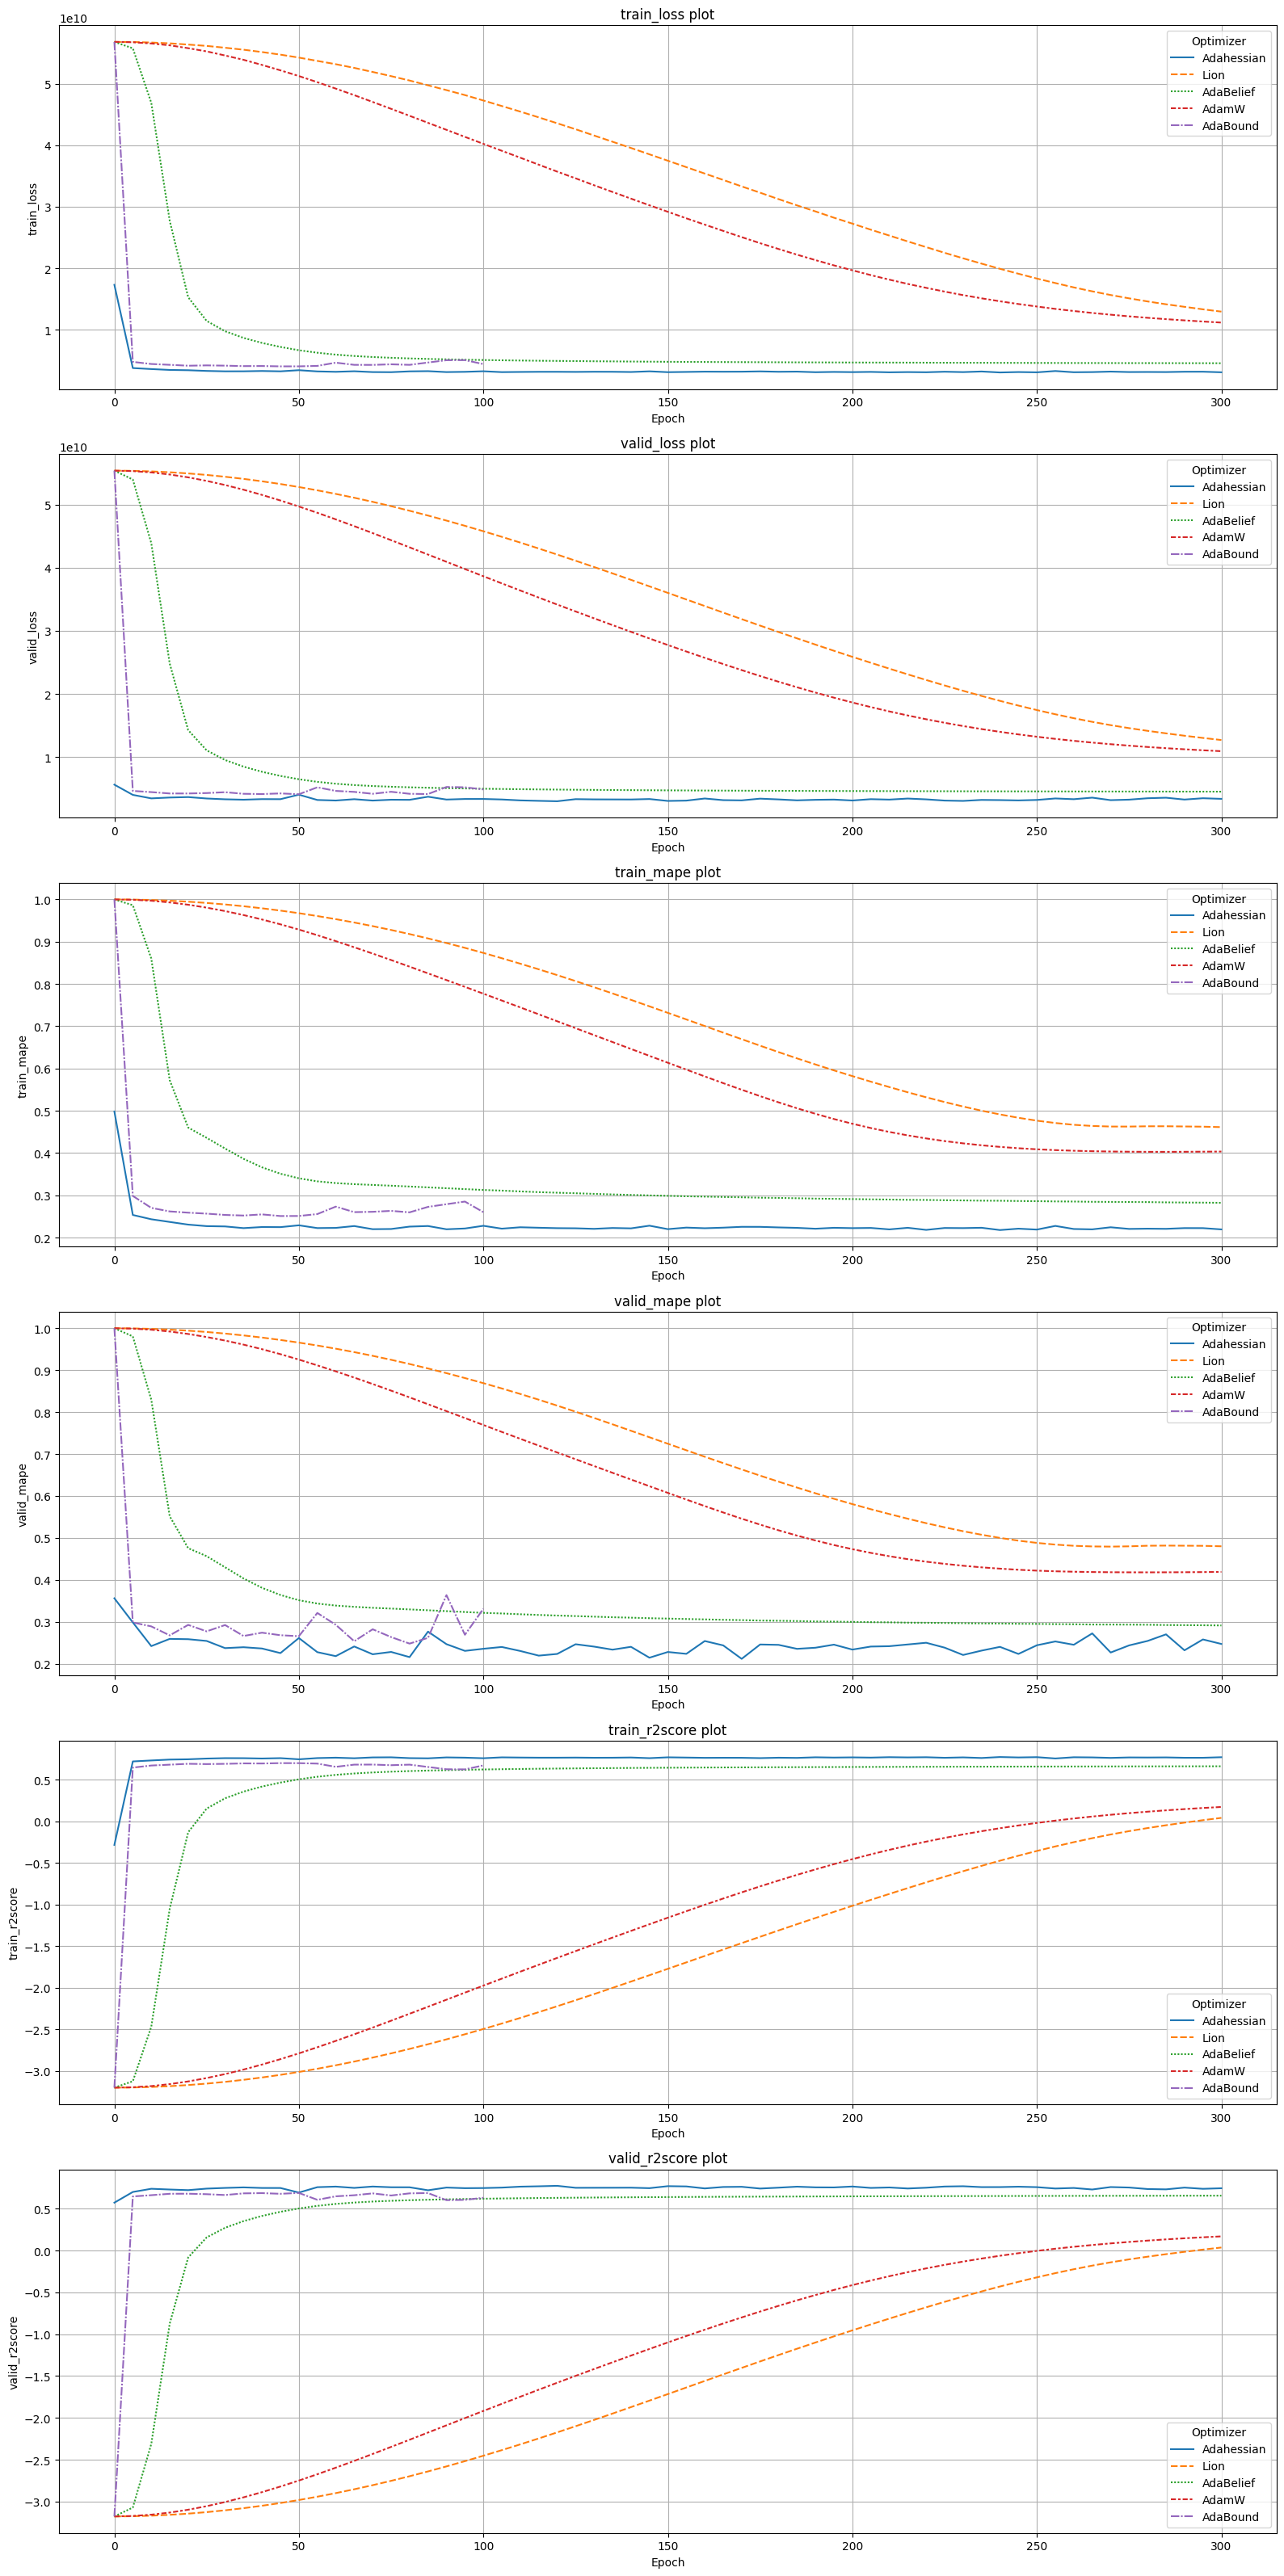

In [17]:
def plot_results(results: dict,
                 exclude_metrics: list | None = None,
                 epoch_step: int = 5,
                 test_num_epochs: int = 301,
                 epoch_limit: int = 50):
    if exclude_metrics is None:
        exclude_metrics = []
    plot_data = pd.DataFrame(results)
    plot_data = plot_data.drop(plot_data.index[plot_data.index.to_series().str.startswith("test_")], axis=0)
    optimizer_names = [repr(i)[repr(i).rfind('.') + 1: -3] for i in plot_data.columns]
    plot_data.columns = optimizer_names
    
    f, axs = plt.subplots(len(plot_data.index) - len(exclude_metrics), 1, figsize=(16, 32), squeeze=False)
    x_epochs = list(range(0, test_num_epochs, epoch_step))
    epoch_limit = 50
    
    for s, metric in enumerate(plot_data.index):
        if metric in exclude_metrics:
            continue
        metric_runs_raw = plot_data.loc[metric].values
        y_values_np = np.stack(metric_runs_raw) if not isinstance(metric_runs_raw, torch.Tensor) else np.stack(metric_runs_raw.cpu())
        df_to_plot = pd.DataFrame(y_values_np.T, index=x_epochs, columns=optimizer_names)
        sns.lineplot(
            data=df_to_plot,
            ax=axs[s, 0],
        )
    
        axs[s, 0].set_title(f"{metric} plot")
        axs[s, 0].set_xlabel("Epoch")
        #axs[s, 0].set_xlim(left=0, right=epoch_limit)
        axs[s, 0].set_ylabel(metric)
        axs[s, 0].grid(True)
        axs[s, 0].legend(title='Optimizer')
    
    plt.tight_layout()
    plt.show()

plot_results(results)

## Спринт 4.  
- Взять другой датасет (желательно под классификацию, чтоб был другой тип задачи )  
- Поработать с циклом подготовки модели (деление train, val, test)  
- Постараться аргументировать почему именно такие гиперпараметры дают хорошие результаты  

Посмотрим другой датасет: `cifar10`, и решим задачу классификации на нем.  

In [18]:
transforms = v2.Compose([ToTensor(),
                         v2.ToDtype(torch.float32, scale=True),
                         v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
cifar_trainset = CIFAR10(root='data',
                         train=True,
                         transform=transforms,
                         download=True)
cifar_testset = CIFAR10(root='data',
                        train=False,
                        transform=transforms,
                        download=True)
cifar_train_subset, cifar_valid_subset = random_split(
    cifar_trainset,
    [int(0.8*len(cifar_trainset)), len(cifar_trainset)-int(0.8*len(cifar_trainset))],
)
classes = ['plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)

Files already downloaded and verified
Files already downloaded and verified


Введем новую тривиальную модель для решения классификационной задачи.   

In [19]:
class SimpleClassificationModel(nn.Module):
    def __init__(
        self,
        input_shape: int = 8,
        hidden_units: int = 16,
        output_shape: int = num_classes,
        activation_function: Optional[torch.nn.Module] = None,
        normalization: Optional[torch.nn.Module] = None,
        dropout: Optional[torch.nn.Module] = None,
    ) -> None:
        """SimpleClassificationModel initializer

        Args:
            input_shape (int): Number of units in input layer
            hidden_units (int): Number of units in hidden layers
            output_shape (int): Number of units in output layer
            activation_function (Optional[torch.nn.Module], optional): Activation function. Defaults to None.
            normalization (Optional[torch.nn.Module], optional): Use batch or layer normalization. Defaults to None.
            dropout (Optional[torch.nn.Module], optional): Dropout layer. Defaults to None.
        """
        super().__init__()

        self.block = nn.Sequential(
            nn.Linear(
                in_features=input_shape,
                out_features=hidden_units,
                device=device,
            ),
            nn.Identity() if normalization is None else normalization,
            nn.Identity() if activation_function is None else activation_function,
            nn.Identity() if dropout is None else dropout,
            
            nn.Linear(
                in_features=hidden_units,
                out_features=output_shape,
                device=device,
            ),
            nn.Flatten(),
            nn.Linear(
                in_features=32*3*output_shape,
                out_features=output_shape,
                device=device,
            ),
            nn.Softmax(dim=1),
        )

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """Method for forward pass.

        Args:
            X (torch.Tensor): Input data.

        Returns:
            torch.Tensor: Result of computations.
        """
        return self.block(X)

In [20]:
summary(SimpleClassificationModel(input_shape=INPUT_SHAPE, 
                                      hidden_units=HIDDEN_UNITS, 
                                      output_shape=num_classes, 
                                      activation_function=nn.ReLU(),
                                     ).to(device))

Layer (type:depth-idx)                   Param #
SimpleClassificationModel                --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       144
│    └─Identity: 2-2                     --
│    └─ReLU: 2-3                         --
│    └─Identity: 2-4                     --
│    └─Linear: 2-5                       170
│    └─Flatten: 2-6                      --
│    └─Linear: 2-7                       9,610
│    └─Softmax: 2-8                      --
Total params: 9,924
Trainable params: 9,924
Non-trainable params: 0

Обучим нашу модель

In [21]:
ray.shutdown()
ray.init()

INPUT_SHAPE = 32
HIDDEN_UNITS = 64
OUTPUT_SHAPE = num_classes
NUM_EPOCHS = 5
EPOCH_STEP = 1
BATCH_SIZE = 64

writer = create_writer(
    experiment_name="classification",
    model_name="simple_cls_model", 
)

cls_analysis_optimizer = {}
classification_metrics = {"accuracy": Accuracy("multiclass", num_classes=num_classes), 
                          "f1score": F1Score("multiclass", num_classes=num_classes),}
reporter = JupyterNotebookReporter(metric_columns=["test_loss"], 
                                   mode="min", 
                                   print_intermediate_tables=False)

cifar_train_subset_ref = ray.put(cifar_train_subset)
cifar_valid_subset_ref = ray.put(cifar_valid_subset)
cifar_testset_ref = ray.put(cifar_testset)

for metric in classification_metrics:
    reporter.add_metric_column(f"valid_{metric}")

for optimizer_type in optimizer_params.keys():
    
    def wrap(config: dict) -> None:
        """Wrapper function for tuning hyperparameters.
    
        Args:
            config: A dict whose keys are parameters to be tuned and values that the parameter can take.

        """
        cifar_train_dataloader = DataLoader(dataset=ray.get(cifar_train_subset_ref),
                                           batch_size=BATCH_SIZE,
                                           shuffle=True,
                                           num_workers=2)
        cifar_valid_dataloader = DataLoader(dataset=ray.get(cifar_valid_subset_ref),
                                           batch_size=BATCH_SIZE,
                                           shuffle=True,
                                           num_workers=2)
        cifar_test_dataloader = DataLoader(dataset=ray.get(cifar_testset_ref),
                                           batch_size=BATCH_SIZE,
                                           shuffle=True,
                                           num_workers=2)
        
        
        model = SimpleClassificationModel(input_shape=INPUT_SHAPE, 
                                      hidden_units=HIDDEN_UNITS, 
                                      output_shape=num_classes, 
                                      activation_function=nn.ReLU(),
                                     ).to(device)
        loss_fn = torch.nn.CrossEntropyLoss()
        optimizer = optimizer_type(model.parameters(), **{i: config[i] for i in config if i in optimizer_params[optimizer_type]})
        d = train(
             model=model,
             train_dataloader=cifar_train_dataloader,
             valid_dataloader=cifar_valid_dataloader,
             test_dataloader=cifar_test_dataloader,
             loss_fn=loss_fn,
             metrics=classification_metrics,
             optimizer=optimizer,
             epochs=NUM_EPOCHS,
             device=device,
             #scheduler=scheduler,
             epoch_step=EPOCH_STEP,
         )
        tune.report({"test_loss": d["test_loss"]} | {f"test_{i}": d[f"test_{i}"] for i in classification_metrics})
        
    analysis = tune.run(
        wrap,
        config={str(key): value for key, value in optimizer_params[optimizer_type].items()},
        scheduler=ASHAScheduler(metric='test_accuracy', mode='max'),
        #num_samples=100,
        progress_reporter=reporter,
        resources_per_trial={"cpu": 2, 
                             "gpu": 1,
                             },
        log_to_file=True,
    )
    cls_analysis_optimizer[optimizer_type] = analysis


2025-04-29 15:50:58,475	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(pid=340148) 2025-04-29 15:51:06.037676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=340148) 2025-04-29 15:51:06.060871: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=340148) 2025-04-29 15:51:06.067915: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(wrap pid=340148) /usr/local/lib/python3.10/dist-packages/torch/autograd/graph

Trial name,test_accuracy,test_f1score,test_loss
wrap_be408_00000,0.3675,0.3675,2.09174
wrap_be408_00001,0.3909,0.3909,2.06597
wrap_be408_00002,0.4308,0.4308,2.02755
wrap_be408_00003,0.4527,0.4527,2.00748
wrap_be408_00004,0.4493,0.4493,2.00586
wrap_be408_00005,0.4544,0.4544,2.00055
wrap_be408_00006,0.4636,0.4636,1.99243
wrap_be408_00007,0.4554,0.4554,2.00071
wrap_be408_00008,0.4582,0.4582,1.99615
wrap_be408_00009,0.4497,0.4497,2.00706


(pid=340625) 2025-04-29 15:52:32.373641: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(pid=340625) 2025-04-29 15:52:32.395496: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=340147) 2025-04-29 15:51:06.077486: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(wrap pid=340147) /usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:825: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.

Trial name,test_accuracy,test_f1score,test_loss
wrap_4acd1_00000,0.3278,0.3278,2.1393
wrap_4acd1_00001,0.3225,0.3225,2.14291
wrap_4acd1_00002,0.4538,0.4538,2.00327
wrap_4acd1_00003,0.448,0.448,2.0079
wrap_4acd1_00004,0.1589,0.1589,2.30271
wrap_4acd1_00005,0.1189,0.1189,2.34252
wrap_4acd1_00006,0.1054,0.1054,2.35625
wrap_4acd1_00007,0.0966,0.0966,2.36501
wrap_4acd1_00008,0.3218,0.3218,2.14029
wrap_4acd1_00009,0.3114,0.3114,2.15357


(pid=355296) 2025-04-29 16:39:18.714931: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(pid=355296) 2025-04-29 16:39:18.736918: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=355296) 2025-04-29 16:39:18.743602: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered [repeated 2x across cluster]
(pid=355737) 2025-04-29 16:40:39.071511: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x acr

...

2025-04-29 18:04:13,237	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/wrap_2025-04-29_16-59-11' in 0.0639s.
2025-04-29 18:04:13,263	INFO tune.py:1041 -- Total run time: 3902.25 seconds (3902.11 seconds for the tuning loop).
2025-04-29 18:04:13,365	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(pid=383730) 2025-04-29 18:04:21.439118: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(pid=383730) 2025-04-29 18:04:21.461422: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

Trial name,test_accuracy,test_f1score,test_loss
wrap_5b92d_00000,0.4028,0.4028,2.05732
wrap_5b92d_00001,0.399,0.399,2.06117
wrap_5b92d_00002,0.4593,0.4593,1.99585
wrap_5b92d_00003,0.4566,0.4566,2.00004
wrap_5b92d_00004,0.1899,0.1899,2.27094
wrap_5b92d_00005,0.1944,0.1944,2.2674
wrap_5b92d_00006,0.3991,0.3991,2.06074
wrap_5b92d_00007,0.3954,0.3954,2.06044
wrap_5b92d_00008,0.4593,0.4593,1.99991
wrap_5b92d_00009,0.4637,0.4637,1.99611


(pid=384203) 2025-04-29 18:05:40.709398: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(pid=384203) 2025-04-29 18:05:40.731159: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=384203) 2025-04-29 18:05:40.737723: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered [repeated 2x across cluster]
(pid=384643) 2025-04-29 18:06:59.440433: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x acr

Trial name,test_accuracy,test_f1score,test_loss
wrap_99223_00000,0.1943,0.1943,2.29353
wrap_99223_00001,0.1568,0.1568,2.29566
wrap_99223_00002,0.3479,0.3479,2.11379
wrap_99223_00003,0.352,0.352,2.10986
wrap_99223_00004,0.3967,0.3967,2.06203
wrap_99223_00005,0.399,0.399,2.06081
wrap_99223_00006,0.4061,0.4061,2.05249
wrap_99223_00007,0.4219,0.4219,2.03969
wrap_99223_00008,0.1103,0.1103,2.30183
wrap_99223_00009,0.1089,0.1089,2.30218


(pid=389621) 2025-04-29 18:21:48.689718: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(pid=389621) 2025-04-29 18:21:48.712015: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=389621) 2025-04-29 18:21:48.720911: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered [repeated 2x across cluster]
(wrap pid=389148) /usr/local/lib/python3.10/dist-packages/adabound/adabound.py:94: UserWarning: This overload of add_ is deprecated:
(wrap pid=389148) 	add_(Number alpha, Tensor other)
(wrap pid=389148) Consider using one of the following 

In [22]:
optimizer_comparison_acc_df = pd.DataFrame({"Optimizer": [repr(i)[repr(i).rfind('.') + 1: -2] for i in cls_analysis_optimizer], 
                                        "Config": [i.get_best_config(metric=f"test_accuracy", mode="max") for i in cls_analysis_optimizer.values()], 
                                        "Accuracy": [i.get_best_trial(metric=f"test_accuracy", mode="max").last_result[f"test_accuracy"] for i in cls_analysis_optimizer.values()], 
                                        "Time_total_s": [i.get_best_trial(metric=f"test_accuracy", mode="max").last_result['time_total_s'] for i in cls_analysis_optimizer.values()],
                                       })

optimizer_comparison_acc_df

,Optimizer,Config,Accuracy,Time_total_s
0,Adahessian,"{'lr': 0.1, 'weight_decay': 0.0001, 'hessian_power': 0.75}",0.4663,79.313110
1,Lion,"{'lr': 0.0001, 'weight_decay': 0, 'decoupled_weight_decay': False, 'use_triton': False}",0.4538,70.234230
2,AdaBelief,"{'lr': 0.001, 'weight_decay': 0, 'amsgrad': True, 'weight_decouple': False, 'rectify': False, 'print_change_log': False}",0.4666,72.177823
3,AdamW,"{'lr': 0.001, 'weight_decay': 0.01, 'amsgrad': True}",0.4669,71.329326
4,AdaBound,"{'lr': 0.001, 'final_lr': 0.1, 'gamma': 0.0001, 'weight_decay': 0, 'amsbound': False}",0.4657,70.791750


In [23]:
optimizer_comparison_f1_df = pd.DataFrame({"Optimizer": [repr(i)[repr(i).rfind('.') + 1: -2] for i in cls_analysis_optimizer], 
                                        "Config": [i.get_best_config(metric=f"test_f1score", mode="max") for i in cls_analysis_optimizer.values()], 
                                        "F1Score": [i.get_best_trial(metric=f"test_f1score", mode="max").last_result[f"test_f1score"] for i in cls_analysis_optimizer.values()], 
                                        "Time_total_s": [i.get_best_trial(metric=f"test_f1score", mode="max").last_result['time_total_s'] for i in cls_analysis_optimizer.values()],
                                       })

optimizer_comparison_f1_df

,Optimizer,Config,F1Score,Time_total_s
0,Adahessian,"{'lr': 0.1, 'weight_decay': 0.0001, 'hessian_power': 0.75}",0.4663,79.313110
1,Lion,"{'lr': 0.0001, 'weight_decay': 0, 'decoupled_weight_decay': False, 'use_triton': False}",0.4538,70.234230
2,AdaBelief,"{'lr': 0.001, 'weight_decay': 0, 'amsgrad': True, 'weight_decouple': False, 'rectify': False, 'print_change_log': False}",0.4666,72.177823
3,AdamW,"{'lr': 0.001, 'weight_decay': 0.01, 'amsgrad': True}",0.4669,71.329326
4,AdaBound,"{'lr': 0.001, 'final_lr': 0.1, 'gamma': 0.0001, 'weight_decay': 0, 'amsbound': False}",0.4657,70.791750


**Анализ по оптимизаторам:**

1.  Adahessian (`{'lr': 0.1, 'weight_decay': 0.0001, 'hessian_power': 0.75}` | F1=0.4663 | Time=79.3s)
    *   `lr = 0.1`:** Adahessian часто требует более высоких `lr`, чем Adam, так как информация о кривизне (Гессиан) уже масштабирует градиент. 0.1 - довольно высокое значение, что соответствует ожиданиям.
    *   `weight_decay = 0.0001`: Очень слабая L2-регуляризация. Возможно, использование информации о кривизне само по себе помогает избегать "острых" минимумов, которые плохо обобщаются, снижая потребность в сильной явной регуляризации.
    *   `hessian_power = 0.75`: Управляет тем, насколько сильно Гессиан влияет на шаг. Значение меньше 1.0 (как в методе Ньютона) означает некоторое подавление, возможно, для стабильности.
    *   Результат: Достиг хорошего F1, сравнимого с лучшими. Это говорит о том, что информация о кривизне была полезна. Однако он самый медленный, так как вычисление (скорее аппроксимации) Гессиана требует больше вычислений на каждом шаге.

2.  Lion (`{'lr': 0.0001, 'weight_decay': 0, 'decoupled_weight_decay': False, ...}` | F1=0.4538 | Time=70.2s)
    *   `lr = 0.0001`: Lion часто требует меньших `lr`, чем Adam, так как величина шага определяется только `lr` (знак не несет информации о величине градиента). 1e-4 - это довольно низкое значение.
    *   `weight_decay = 0`: Оптимальной конфигурацией оказалось отсутствие L2-регуляризации. Возможно, sign-based обновления сами по себе имеют некий неявный регуляризующий эффект, или же явная регуляризация плохо сочеталась с этим оптимизатором в данном поиске.
    *   `decoupled_weight_decay = False`: Стандартный способ применения weight decay (но он равен 0).
    *   Результат: Показал наименьший F1-score. Вероятно, комбинация sign-based обновлений и отсутствия явной регуляризации не позволила модели хорошо обобщиться. Он самый быстрый, так как его шаг обновления вычислительно очень прост.

3.  AdaBelief (`{'lr': 0.001, 'weight_decay': 0, 'amsgrad': True, ...}` | F1=0.4666 | Time=72.2s)
    *   `lr = 0.001`: Стандартное, часто эффективное значение для Adam-подобных оптимизаторов.
    *   `weight_decay = 0`: Снова отсутствие явной регуляризации. Возможно, адаптивный механизм AdaBelief (уменьшение шага при большой вариации градиента) сам по себе обеспечивает достаточную стабильность или имеет неявный регуляризующий эффект, который оказался достаточным для найденной конфигурации.
    *   `amsgrad = True`: Использование AMSGrad (гарантирует невозрастание второго момента) помогло стабилизировать обучение или улучшить сходимость для AdaBelief в этом случае.
    *   Результат: Очень хороший F1, почти лучший. Адаптивный механизм, вероятно, помог найти хороший минимум даже без явной регуляризации. Скорость сравнима с AdamW.

4.  AdamW (`{'lr': 0.001, 'weight_decay': 0.01, 'amsgrad': True}` | F1=0.4669 | Time=71.3s)**
    *   `lr = 0.001`: Стандартный `lr`.
    *   `weight_decay = 0.01`: Это самое высокое значение `weight_decay` из всех рассмотренных оптимизаторов и самое высокое в сетке поиска для AdamW. Такая сильная регуляризация оказалась необходима для простой модели на CIFAR-10, чтобы предотвратить переобучение и улучшить обобщающую способность. 
    *   `amsgrad = True`: Помогло стабилизировать обучение.
    *   Результат: Лучший F1-score. Успех обусловлен комбинацией стандартного `lr`, эффективного механизма decoupled weight decay и **критически важной сильной регуляризации (wd=0.01)**, которая компенсировала простоту модели. Скорость стандартная для Adam-подобных.

5.  AdaBound (`{'lr': 0.001, 'final_lr': 0.1, 'gamma': 0.0001, 'weight_decay': 0, ...}` | F1=0.4657 | Time=70.8s)**
    *   `lr = 0.001`: Начальная (Adam-подобная) скорость обучения.
    *   `final_lr = 0.1`: Конечная (SGD-подобная) скорость обучения, высокое значение  
    *   `gamma = 0.0001`: Параметр, контролирующий скорость перехода и форму границ. Очень маленькое значение означает, что границы начинают действовать очень поздно или очень слабо.
    *   `weight_decay = 0`: Без явной регуляризации.
    *   Интерпретация `final_lr` и `gamma`: Комбинация очень высокого `final_lr` и очень маленького `gamma` может означать, что оптимизатор большую часть времени работал в режиме, близком к Adam, и переход к "ограниченному" режиму был либо очень поздним, либо границы были настолько широкими (из-за высокого `final_lr`), что практически не влияли на обучение.
    *   Результат: Хороший F1, сравнимый с лучшими. Вероятно, начальная фаза, похожая на Adam, обеспечила хороший прогресс. Отсутствие регуляризации, возможно, обуславливается механизмом границ (даже слабых), который дал стабильность. Скорость близка к AdamW.

**Выводы:**

*   Все оптимизаторы показали очень близкие результаты, вероятнее всего, модель неспособна полностью решить задачу на CIFAR-10 из-за простой архитертуры.
*   AdamW показал лучший результат за счет сильной и эффективно примененной регуляризации (`weight_decay=0.01`), которая была критична для данной модели.
*   Другие адаптивные методы (Adahessian, AdaBelief, AdaBound) также смогли найти хорошие решения, но их лучшие конфигурации по результатам поиска обошлись без явной регуляризации. Возможно, их внутренние механизмы адаптации или динамические границы обеспечили достаточную стабильность/регуляризацию *в рамках найденных гиперпараметров*, или же поиск не нашел оптимальной комбинации с `weight_decay > 0` для них.
*   Lion показал себя хуже всех, вероятно, из-за отсутствия регуляризации и специфики sign-based обновлений для этой задачи.

In [24]:
cls_analysis_optimizer[optimizer_type].dataframe().shape

(216, 22)

In [25]:
results = {}
TEST_NUM_EPOCHS = 101
TEST_EPOCH_STEP = 5

cifar_train_dataloader = DataLoader(dataset=cifar_train_subset,
                                   batch_size=BATCH_SIZE,
                                   shuffle=True,
                                   num_workers=2)
cifar_valid_dataloader = DataLoader(dataset=cifar_valid_subset,
                                   batch_size=BATCH_SIZE,
                                   shuffle=True,
                                   num_workers=2)
cifar_test_dataloader = DataLoader(dataset=cifar_testset,
                                   batch_size=BATCH_SIZE,
                                   shuffle=True,
                                   num_workers=2)

classification_metrics = {"accuracy": Accuracy("multiclass", num_classes=num_classes), 
                          "f1score": F1Score("multiclass", num_classes=num_classes),
                          "confusion_matrix": MulticlassConfusionMatrix(num_classes=num_classes),
                          "multiclass_roc": MulticlassROC(num_classes=num_classes)
                          }

for optimizer_type, config in zip(optimizer_params.keys(), optimizer_comparison_acc_df['Config']):
    model = SimpleClassificationModel(input_shape=INPUT_SHAPE, 
                                      hidden_units=HIDDEN_UNITS, 
                                      output_shape=num_classes, 
                                      activation_function=nn.ReLU(),
                                     ).to(device)
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = optimizer_type(model.parameters(), **{i: config[i] for i in config if i in optimizer_params[optimizer_type]})
    start = time.perf_counter()
    d = train(
             model=model,
             train_dataloader=cifar_train_dataloader,
             valid_dataloader=cifar_valid_dataloader,
             test_dataloader=cifar_test_dataloader,
             loss_fn=loss_fn,
             metrics=classification_metrics,
             optimizer=optimizer,
             epochs=TEST_NUM_EPOCHS,
             device=device,
             #scheduler=scheduler,
             epoch_step=TEST_EPOCH_STEP,
         )
    end = time.perf_counter()
    print(f"{str(optimizer_type)} was trained for {end-start} seconds")
    results[str(optimizer_type)] = d

<class 'torch_optimizer.adahessian.Adahessian'> was trained for 1022.7055885560003 seconds
<class 'lion_pytorch.lion_pytorch.Lion'> was trained for 969.9011098219999 seconds
AMSGrad enabled in AdaBelief
<class 'adabelief_pytorch.AdaBelief.AdaBelief'> was trained for 984.1290832699997 seconds
<class 'torch.optim.adamw.AdamW'> was trained for 958.8195345729982 seconds
<class 'adabound.adabound.AdaBound'> was trained for 978.3018665119998 seconds


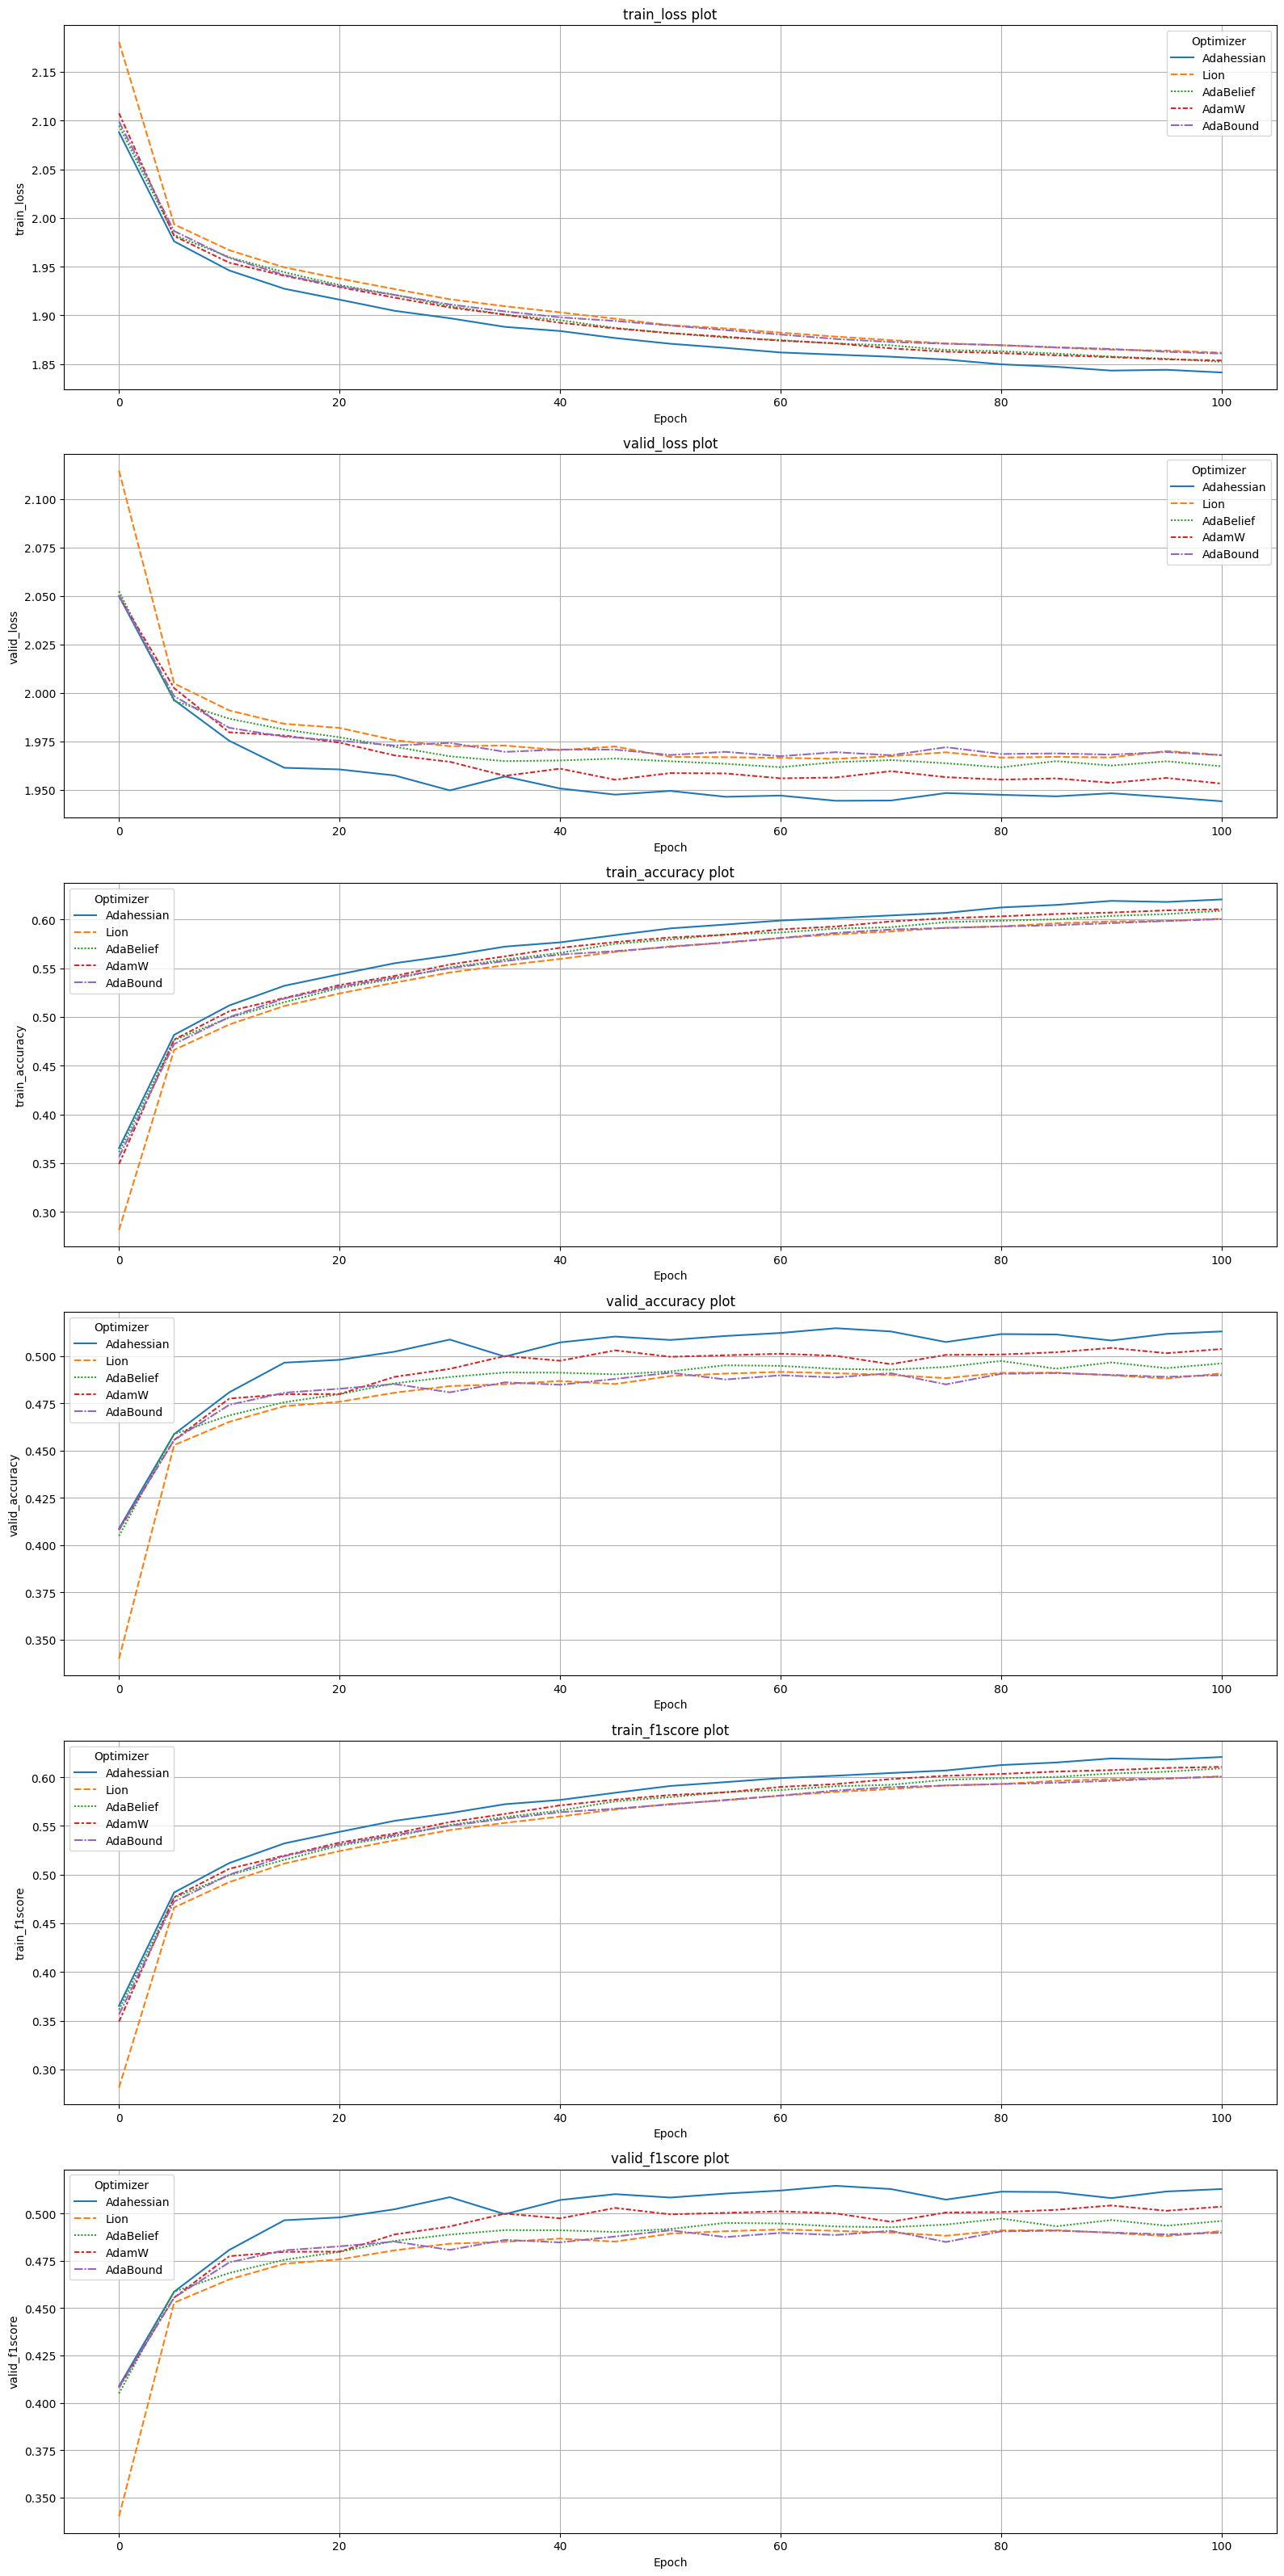

In [26]:
exclude_metrics = ["train_confusion_matrix", "valid_confusion_matrix", "train_multiclass_roc", "valid_multiclass_roc"]
plot_results(results, exclude_metrics=exclude_metrics, test_num_epochs=TEST_NUM_EPOCHS, epoch_step=TEST_EPOCH_STEP)

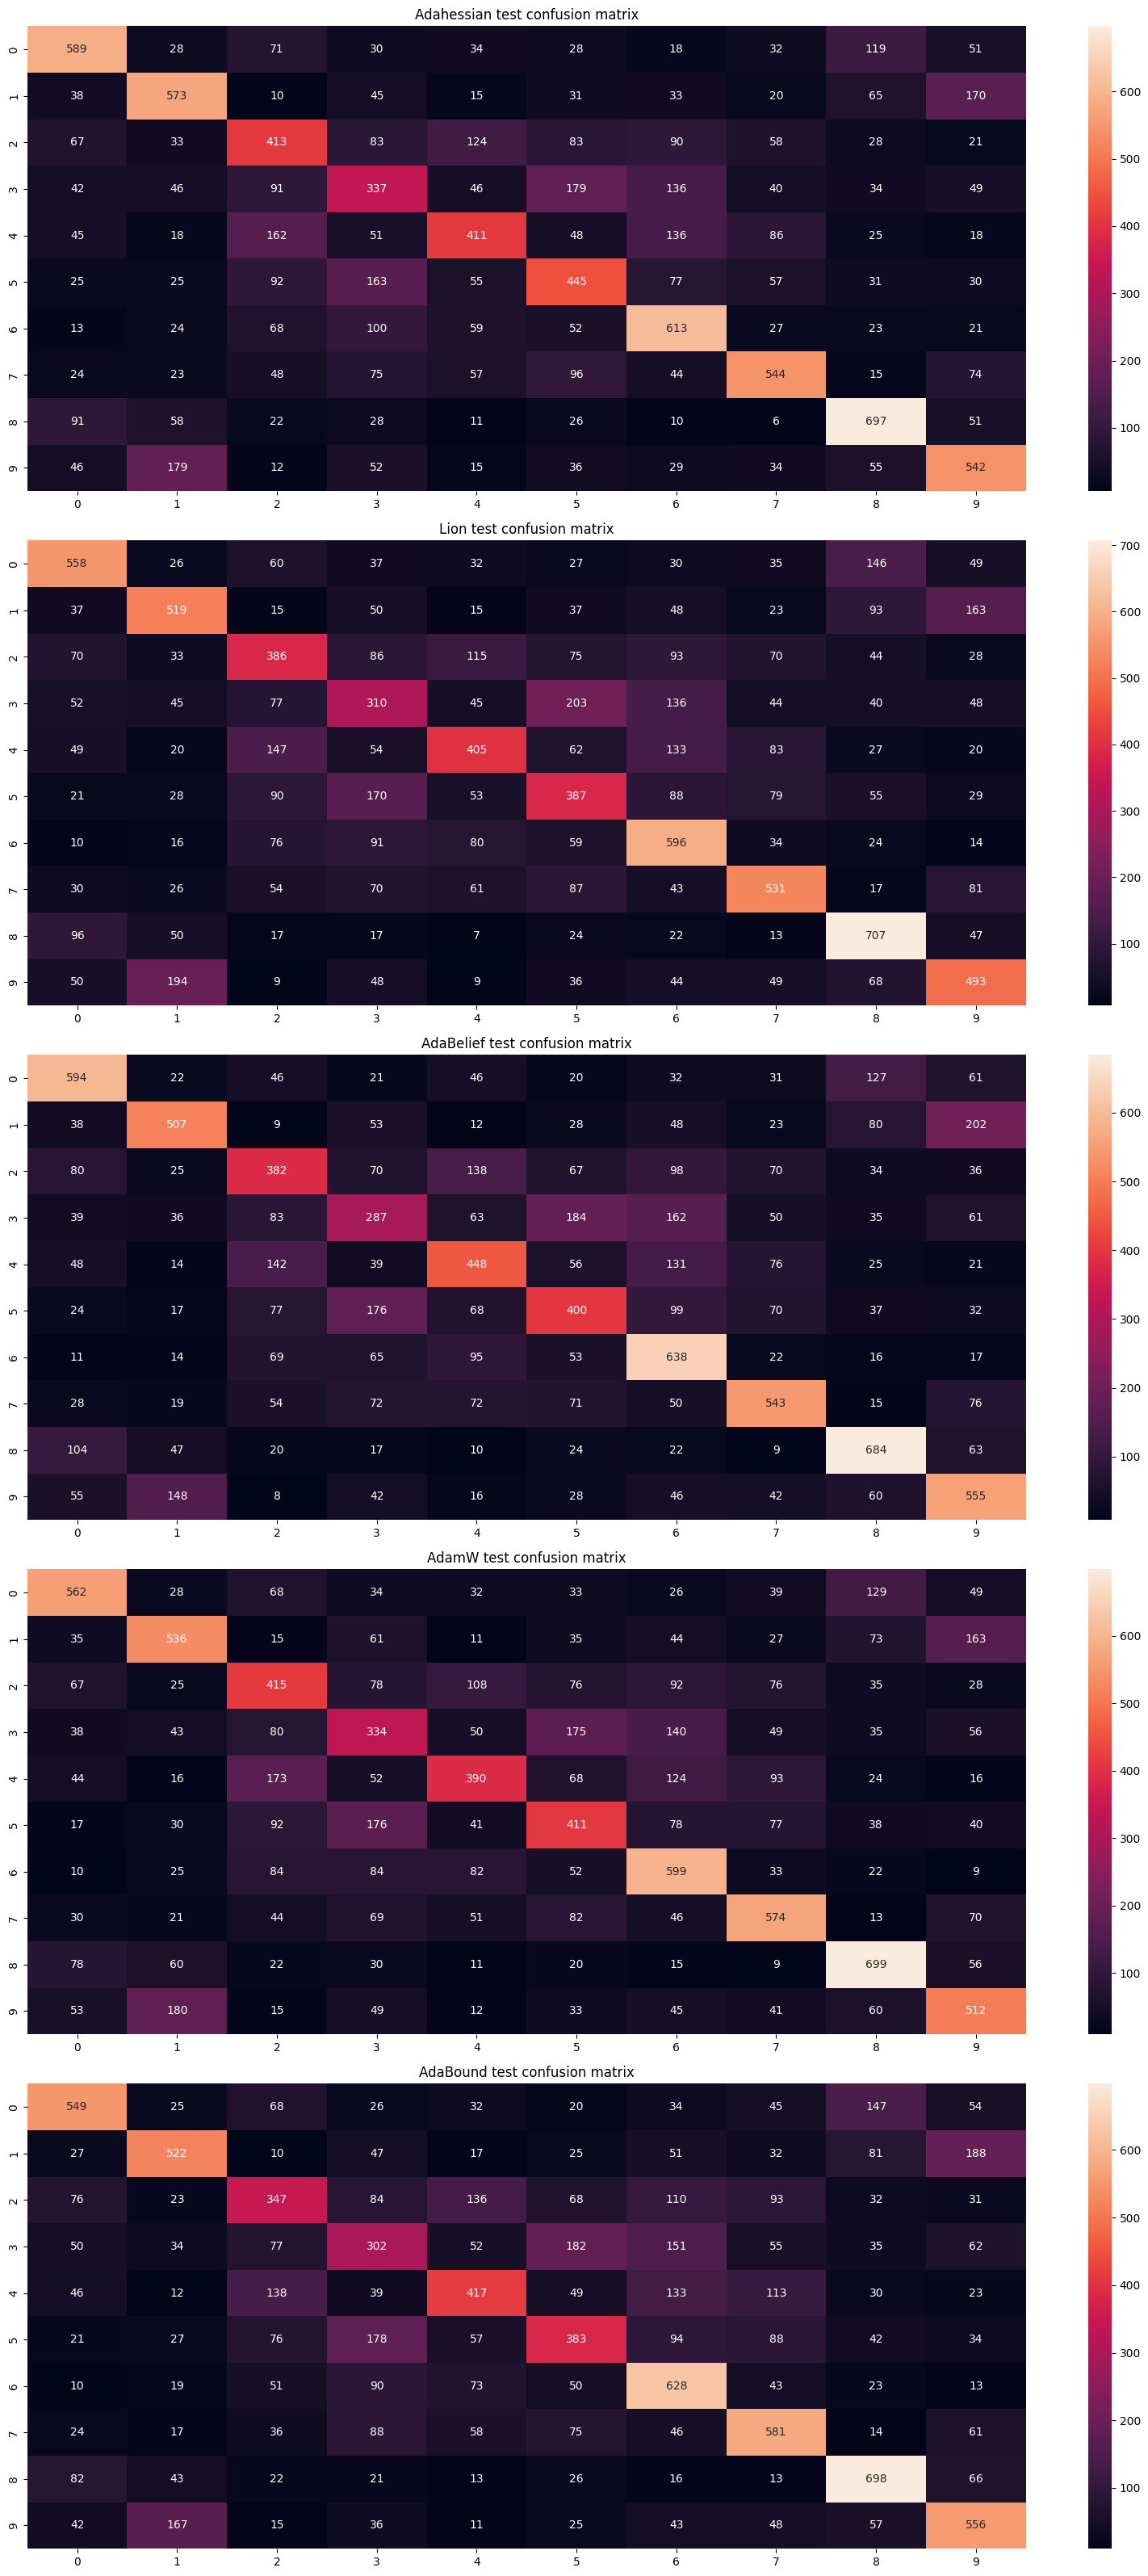

In [27]:
def plot_confusion_matrices_results(results: dict):
    optimizer_names = [repr(i)[repr(i).rfind('.') + 1: -3] for i in results]
    
    f, axs = plt.subplots(len(results), 1, figsize=(16, 32), squeeze=False)
    
    for s, optimizer_type in enumerate(results):
        train_cm = results[optimizer_type]["test_confusion_matrix"].cpu()
        sns.heatmap(train_cm, annot=True, ax=axs[s, 0], fmt='.20g')
        axs[s, 0].set_title(f"{optimizer_names[s]} test confusion matrix")
        
    plt.tight_layout()
    plt.show()

plot_confusion_matrices_results(results)

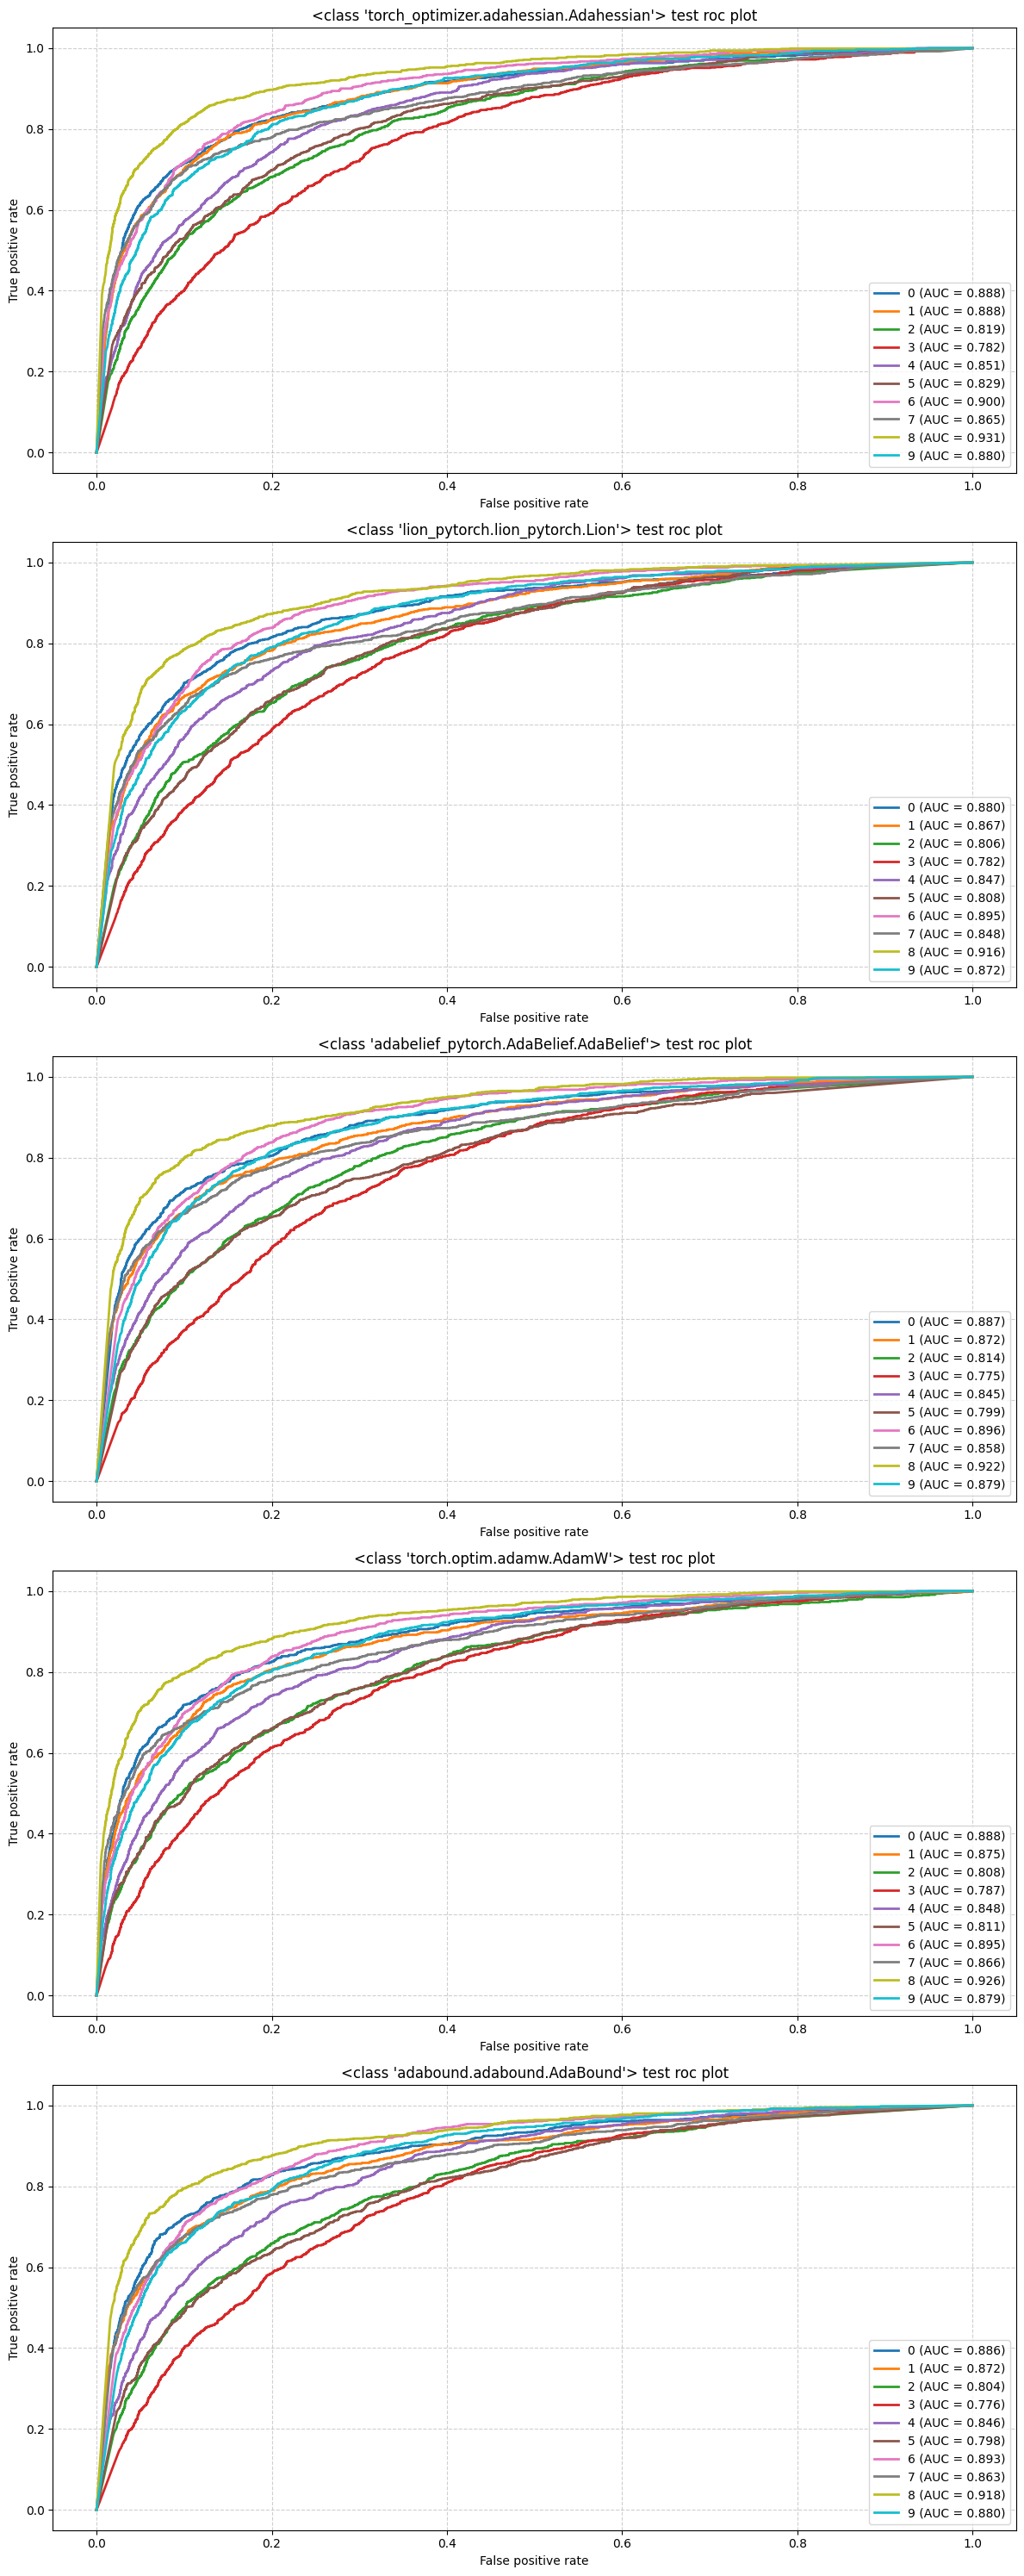

In [28]:
def test_plot_roc_results(results: dict):
    optimizer_names = [repr(i)[repr(i).rfind('.') + 1: -3] if isinstance(i, type) else str(i) for i in results]

    fig_height = 6 * len(results)
    f, axs = plt.subplots(len(results), 1, figsize=(12, fig_height), squeeze=False)

    for s, optimizer_type in enumerate(results):
        current_ax = axs[s, 0]
        metric = MulticlassROC(num_classes=num_classes)
        curve_input_data = results[optimizer_type]["test_multiclass_roc"]

        try:
            preds, target = curve_input_data
            metric.update(preds, target)
            computed_data, returned_ax = metric.plot(score=True, ax=current_ax)

        except ValueError:
             print(f"Warning: Assuming curve data for {optimizer_names[s]} is (fpr, tpr, thresholds). Manually calculating AUC.")
             from sklearn.metrics import auc
             fpr_list, tpr_list, _ = curve_input_data
             computed_data = {}

             returned_ax = metric.plot(curve=curve_input_data, score=False, ax=current_ax)[1]

             auc_scores = []
             if isinstance(fpr_list, list) and isinstance(tpr_list, list):
                 for i in range(num_classes):
                     fpr = fpr_list[i]
                     tpr = tpr_list[i]
                     if hasattr(fpr, 'cpu'): fpr = fpr.cpu().numpy()
                     if hasattr(tpr, 'cpu'): tpr = tpr.cpu().numpy()
                     roc_auc = auc(fpr, tpr)
                     auc_scores.append(roc_auc)

                 computed_data['roc_auc_per_class'] = torch.tensor(auc_scores) if 'torch' in sys.modules else np.array(auc_scores)
             else:
                 print(f"Could not compute AUC for {optimizer_names[s]} due to unexpected curve data structure.")

        handles, original_labels = current_ax.get_legend_handles_labels()

        new_labels = []
        auc_values = None

        if isinstance(computed_data, dict):
            if 'roc_auc_per_class' in computed_data:
                auc_values = computed_data['roc_auc_per_class']
            elif 'auc_per_class' in computed_data:
                 auc_values = computed_data['auc_per_class']
        elif isinstance(computed_data, (list, tuple, torch.Tensor)):
             if len(computed_data) >= num_classes:
                 auc_values = computed_data

        if auc_values is not None:
             if hasattr(auc_values, 'tolist'):
                 auc_list = auc_values.tolist()
             else:
                 auc_list = list(auc_values)

             if len(auc_list) >= num_classes and len(handles) >= num_classes:
                 for i in range(len(handles)):
                     if i < num_classes:
                         base_label = original_labels[i] if i < len(original_labels) else f"Class {i}"
                         auc_score = auc_list[i]
                         new_labels.append(f"{base_label} (AUC = {auc_score:.3f})") # Форматируем AUC
                     else:
                         new_labels.append(original_labels[i] if i < len(original_labels) else f"Curve {i}")
             else:
                  new_labels = original_labels
        else:
            new_labels = original_labels
        if handles:
            current_ax.legend(handles, new_labels)

        current_ax.set_title(f"{optimizer_names[s]} test roc plot")
        current_ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
test_plot_roc_results(results)